# Анализ данных и сравнение моделей ML

**Цель:** Сравнить различные модели машинного обучения на синтетическом датасете для задачи классификации.

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('synthetic_classification_dataset.csv')
print(f"Размер датасета: {df.shape}")
print("\nПервые 3 строки:")
print(df.head(3))

Размер датасета: (400, 7)

Первые 3 строки:
   income_level  age_group  credit_score_derived  debt_ratio_derived  \
0  33138.455223  10.016433            680.875378           -0.107221   
1  36023.507903  11.947170            672.222590           -0.063672   
2  63258.400944  17.332188            597.558112            0.035761   

   zip_code  phone_area_code  target  
0     77841              489       1  
1     42134              787       1  
2     84522              895       2  


In [3]:
# Базовый анализ данных
print("ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")
print(f"Количество классов: {df['target'].nunique()}")
print(f"Распределение классов: {df['target'].value_counts().to_dict()}")

# Описательная статистика
print("\nОписательная статистика")
print(df.describe().round(2))

ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ
Пропущенные значения: 0
Количество классов: 3
Распределение классов: {2: 135, 1: 134, 0: 131}

Описательная статистика
       income_level  age_group  credit_score_derived  debt_ratio_derived  \
count        400.00     400.00                400.00              400.00   
mean       55331.62      24.36                599.35                0.25   
std        15270.82      19.61                 66.18                0.50   
min        15780.58      -0.70                417.10               -0.38   
25%        39933.78      10.60                555.74               -0.10   
50%        63117.69      15.70                601.39                0.03   
75%        66300.14      37.85                659.35                0.60   
max        74666.23      90.46                721.37                1.92   

       zip_code  phone_area_code  target  
count    400.00           400.00  400.00  
mean   54826.46           594.63    1.01  
std    25366.75           235.55    0.

КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
debt_ratio_derived: -0.740
age_group: -0.736
credit_score_derived: 0.475
zip_code: -0.037
phone_area_code: -0.026
income_level: -0.020


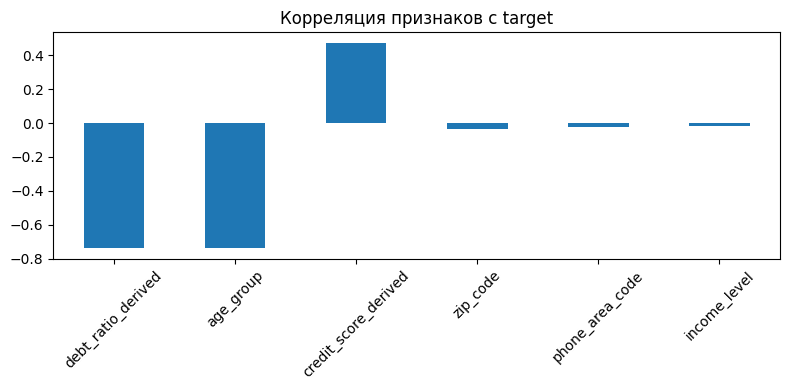

In [4]:
# Анализ корреляций
print("КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
correlations = df.drop('target', axis=1).corrwith(df['target']).sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.3f}")

# Визуализация корреляций
plt.figure(figsize=(8, 4))
correlations.plot(kind='bar')
plt.title('Корреляция признаков с target')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Проверка необходимости масштабирования
print("АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ")
feature_stats = df.drop('target', axis=1).describe().transpose()

max_mean = feature_stats['mean'].max()
min_mean = feature_stats['mean'].min()
scale_diff = (max_mean - min_mean) / min_mean * 100

print(f"Макс. среднее: {max_mean:.2f}")
print(f"Мин. среднее: {min_mean:.2f}")
print(f"Различие в масштабах: {scale_diff:.1f}%")

if scale_diff > 50:
    print("НУЖНО МАСШТАБИРОВАНИЕ")
else:
    print("Масштабирование не обязательно")

АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ
Макс. среднее: 55331.62
Мин. среднее: 0.25
Различие в масштабах: 21811320.2%
НУЖНО МАСШТАБИРОВАНИЕ


In [ ]:
# Training models
results = []
models = {}

print("TRAINING MODELS")

# Logistic Regression
print("Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
metrics, model = train_and_evaluate(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")
results.append(metrics)
models['lr'] = model

# KNN
print("KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
metrics, model = train_and_evaluate(knn, X_train_scaled, X_test_scaled, y_train, y_test, "KNN")
results.append(metrics)
models['knn'] = model

# SVM
print("SVM...")
svm = SVC(random_state=42, probability=True)
metrics, model = train_and_evaluate(svm, X_train_scaled, X_test_scaled, y_train, y_test, "SVM")
results.append(metrics)
models['svm'] = model

# Decision Tree
print("Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
metrics, model = train_and_evaluate(dt, X_train, X_test, y_train, y_test, "Decision Tree")
results.append(metrics)
models['dt'] = model

Train: (320, 6), Test: (80, 6)
Данные подготовлены и масштабированы


In [ ]:
# Naive Bayes
print("Naive Bayes...")
nb = GaussianNB()
metrics, model = train_and_evaluate(nb, X_train, X_test, y_train, y_test, "Naive Bayes")
results.append(metrics)
models['nb'] = model

print("\nAll models trained!")

In [ ]:
# Compare results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print("MODEL COMPARISON")
print(results_df.round(3).to_string(index=False))

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
results_df.plot(kind='bar', x='model', y=['train_acc', 'test_acc'], ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['Train', 'Test'])
axes[0].tick_params(axis='x', rotation=45)

# F1-score
results_df.plot(kind='bar', x='model', y='test_f1', ax=axes[1], color='green')
axes[1].set_title('F1-Score (Test)')
axes[1].tick_params(axis='x', rotation=45)

# Overfitting
results_df.plot(kind='bar', x='model', y='overfitting', ax=axes[2], color='red')
axes[2].set_title('Overfitting')
axes[2].axhline(y=0.1, color='black', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ОБУЧЕНИЕ МОДЕЛЕЙ
Логистическая регрессия...
KNN...
SVM...
Наивный Байес...
Дерево решений...
Случайный лес...
Gradient Boosting...

Все модели обучены!


СРАВНЕНИЕ МОДЕЛЕЙ
              model  train_acc  test_acc  test_f1  overfitting
      Random Forest      1.000     0.950    0.951        0.050
                KNN      0.938     0.938    0.938        0.000
  Gradient Boosting      1.000     0.938    0.938        0.062
        Naive Bayes      0.928     0.925    0.926        0.003
                SVM      0.938     0.925    0.926        0.012
      Decision Tree      0.981     0.925    0.925        0.056
Logistic Regression      0.922     0.900    0.902        0.022


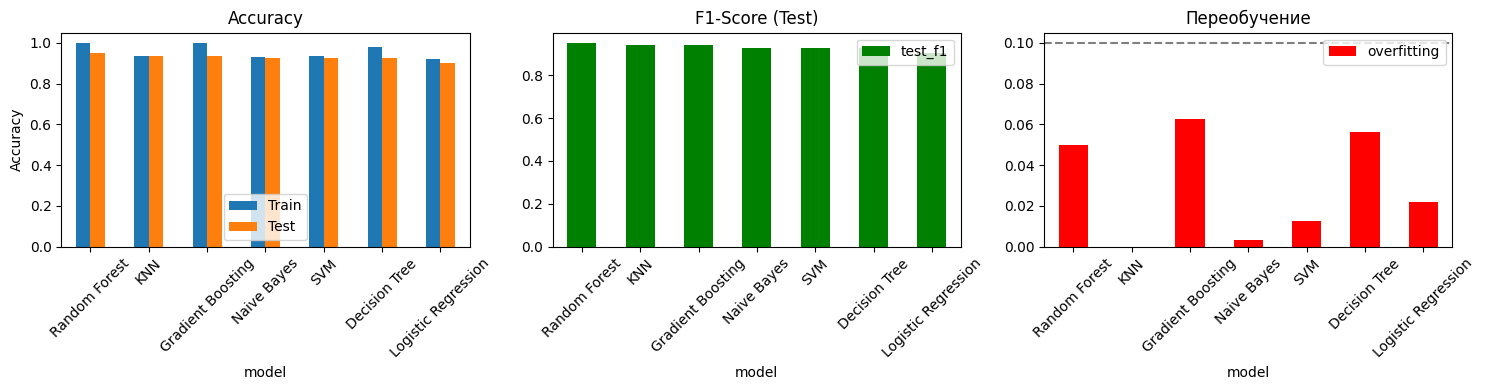

In [ ]:
# Overfitting analysis
print("OVERFITTING ANALYSIS")
overfit_threshold = 0.1

overfitting = results_df[results_df['overfitting'] > overfit_threshold]
stable = results_df[results_df['overfitting'] <= overfit_threshold]

print(f"Models with overfitting (> {overfit_threshold}):")
if len(overfitting) > 0:
    for _, row in overfitting.iterrows():
        print(f"  - {row['model']}: {row['overfitting']:.3f}")
else:
    print("  None")

print(f"\nStable models (<= {overfit_threshold}):")
for _, row in stable.iterrows():
    print(f"  - {row['model']}: {row['overfitting']:.3f}")

In [ ]:
# Top-3 models
print("TOP-3 MODELS")
top_3 = results_df.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"{i}. {row['model']} - F1: {row['test_f1']:.3f}, Accuracy: {row['test_acc']:.3f}")

# Best model
best_model_name = results_df.iloc[0]['model']
print(f"\nBest model: {best_model_name}")

# Detailed report for best model
print("\nDetailed report for best model")
# Map model name to object
model_mapping = {
    'Logistic Regression': models['lr'],
    'KNN': models['knn'],
    'SVM': models['svm'],
    'Naive Bayes': models['nb'],
    'Decision Tree': models['dt']
}

best_model = model_mapping.get(best_model_name)
if best_model:
    # Determine which data to use for prediction
    if best_model_name in ['Logistic Regression', 'KNN', 'SVM']:
        X_test_final = X_test_scaled
    else:
        X_test_final = X_test
    
    y_pred = best_model.predict(X_test_final)
    print(classification_report(y_test, y_pred))

АНАЛИЗ ПЕРЕОБУЧЕНИЯ
Модели с переобучением (> 0.1):
  Нет

Стабильные модели (<= 0.1):
  - Random Forest: 0.050
  - KNN: 0.000
  - Gradient Boosting: 0.062
  - Naive Bayes: 0.003
  - SVM: 0.012
  - Decision Tree: 0.056
  - Logistic Regression: 0.022


In [ ]:
# Conclusions
print("MAIN CONCLUSIONS")
print(f"1. Best model: {best_model_name}")
print(f"2. Quality (F1): {results_df.iloc[0]['test_f1']:.3f}")
print(f"3. Accuracy: {results_df.iloc[0]['test_acc']:.3f}")
print(f"4. Models with overfitting: {len(overfitting)} out of {len(results_df)}")
print(f"5. Scaling required for: Logistic Regression, KNN, SVM")

print("\nSUMMARY")
if len(overfitting) > 0:
    print("- For models with overfitting, regularization or complexity reduction is recommended")
if results_df.iloc[0]['test_f1'] > 0.8:
    print("- Model quality is high, can be used")
else:
    print("- Model quality is poor, additional hyperparameter tuning is recommended")

ТОП-3 МОДЕЛИ
1. Random Forest - F1: 0.951, Accuracy: 0.950
2. KNN - F1: 0.938, Accuracy: 0.938
3. Gradient Boosting - F1: 0.938, Accuracy: 0.938

Лучшая модель: Random Forest

Детальный отчет лучшей модели
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       0.93      0.96      0.95        27
           2       0.93      0.93      0.93        27

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



In [20]:
# Выводы
print("ОСНОВНЫЕ ВЫВОДЫ")
print(f"1. Лучшая модель: {best_model_name}")
print(f"2. Качество (F1): {results_df.iloc[0]['test_f1']:.3f}")
print(f"3. Точность (Accuracy): {results_df.iloc[0]['test_acc']:.3f}")
print(f"4. Моделей с переобучением: {len(overfitting)} из {len(results_df)}")
print(f"5. Масштабирование потребовалось для: Logistic Regression, KNN, SVM")

print("\nИТОГ")
if len(overfitting) > 0:
    print("- Для моделей с переобучением нужно регуляризация или уменьшение сложности")
if results_df.iloc[0]['test_f1'] > 0.8:
    print("- Качество моделей высокое, можно использовать")
else:
    print("- Качество моделей плохое, рекомендуется дополнительная настройка гиперпараметров")

ОСНОВНЫЕ ВЫВОДЫ
1. Лучшая модель: Random Forest
2. Качество (F1): 0.951
3. Точность (Accuracy): 0.950
4. Моделей с переобучением: 0 из 7
5. Масштабирование потребовалось для: Logistic Regression, KNN, SVM

ИТОГ
- Качество моделей высокое, можно использовать
